In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os


datadir1  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/REVISION/ConstantStress/MP0.03_BP0.01/StretchRemodelTest/'
#datadir2  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Data/'
datadir2  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/REVISION/ConstantStress/MP0.03_BP0.01/Stretch/'

plotsdir  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/REVISION/ConstantStress/Plotting/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/|Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
def dfs(graph, start, visited):
    visited.add(start)
    count = 1  # Count the starting node
    for neighbor in graph[start]:
        if neighbor not in visited:
            count += dfs(graph, neighbor, visited)  # Add count from neighbors
    return count

def build_graph(edges):
    graph = {}
    for edge in edges:
        a, b = edge
        if a not in graph:
            graph[a] = []
        if b not in graph:
            graph[b] = []
        graph[a].append(b)
        graph[b].append(a)  # Omit this line for a directed graph
    return graph

def build_graphWithTypes(edges,T):
    graph = {}
    i==0
    for edge in edges:
        a, b, t = edge
        if a not in graph:
            graph[a] = []
        if b not in graph:
            graph[b] = []
        if t==T:
            graph[a].append(b)
            graph[b].append(a)  # Omit this line for a directed graph
    return graph

def largest_connected_component(graph):
    visited = set()
    largest = 0
    for node in graph:
        if node not in visited:
            size = dfs(graph, node, visited)
            largest = max(largest, size)
    return largest

def is_connected(graph, nodes):
    visited = set()
    dfs(graph, next(iter(graph)), visited)
    return len(visited) == len(nodes)

def find_connected_components(graph, nodes):
    visited = set()
    num_components = 0
    for node in nodes:
        if node not in visited:
            dfs(graph, node, visited)
            num_components += 1
    return num_components
    
def calculate_average_degree(graph):
    total_degrees = sum(len(neighbors) for neighbors in graph.values())
    num_nodes = len(graph)
    #print(num_nodes)
    average_degree = total_degrees / num_nodes if num_nodes else 0
    return average_degree

def calculate_average_degree7sNc1(graph):
    total_degrees = sum(len(neighbors) for neighbors in graph.values())
    num_nodes = len(graph)
    #print(num_nodes)
    average_degree = total_degrees / num_nodes if num_nodes else 0
    return average_degree

In [3]:
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','steelblue','slateblue']
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]

In [4]:

### Fetching stress and bond force ####
Press = "-0.05".split()
Press = "-0.01 -0.05 -0.1".split()
p=2
tcyclrel = "1e5".split()
seeds = "1".split()
foldername = datadir1+'runHold1_Stress_tstretch1e4_tcycrel1e5_Press'+Press[p]+'_TimeFrom1509600_RheologyCycles5_seed'+seeds[0]+'/'
#foldername = datadir+'run_Stress_tstretch1e4_tcycrel'+tcyclrel[0]+'_Press'+Press[0]+'_TimeFrom1509600_RheologyCycles5_seed'+seeds[0]+'/'

filename = '/thermo.dat'
thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
etot_, ke_, peBond_,peAngle_, temp_, press_,stressX_,stressY_,stressZ_,AvBondForce_   = thermo.etot,thermo.ke,thermo.peBond,thermo.peAngle,thermo.temp,thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce     
etot, ke, peBond,peAngle, temp, press,stressX,stressY,stressZ,AvBondForce = etot_.values, ke_.values, peBond_.values,peAngle_.values, temp_.values, press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values
xbox_,ybox_ = thermo.boxX, thermo.boxY
xbox,ybox = xbox_.values,ybox_.values
Time_ = thermo.step
Time = Time_.values

#StressXTot.append(list(stressX))
#AvBondForceXTot.append(list(AvBondForce))
zbox = 13

stressXred = np.divide(stressX,np.multiply(np.multiply(xbox,ybox),zbox))
stressYred = np.divide(stressY,np.multiply(np.multiply(xbox,ybox),zbox))
stressZred = np.divide(stressZ,np.multiply(np.multiply(xbox,ybox),zbox))



642
645
641


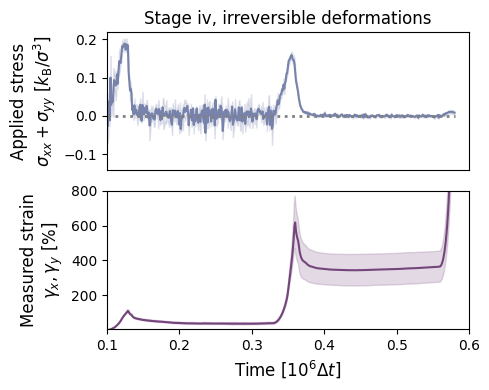

In [11]:
T_End = 641
seeds = "1 2 3".split()
Press = "-0.01 -0.05 -0.1".split()
p=2
stressXred = []
stressYred = []
stressZred = []
xboxx = []
yboxx = []
meanstrain = []
for s in range(len(seeds)):
    if p==2:
        foldername = datadir1+'runHold1_Stress_tstretch1e4_tcycrel1e5_Press'+Press[p]+'_TimeFrom1509600_RheologyCycles5_seed'+seeds[s]+'/'
    if p==1:
        foldername = datadir1+'runHold3_Stress_tstretch1e4_tcycrel1e5_Press'+Press[p]+'_TimeFrom1509600_RheologyCycles5_seed'+seeds[s]+'/'
    filename = '/thermo.dat'
    thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
    etot_, ke_, peBond_,peAngle_, temp_, press_,stressX_,stressY_,stressZ_,AvBondForce_   = thermo.etot,thermo.ke,thermo.peBond,thermo.peAngle,thermo.temp,thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce     
    etot, ke, peBond,peAngle, temp, press,stressX,stressY,stressZ,AvBondForce = etot_.values, ke_.values, peBond_.values,peAngle_.values, temp_.values, press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values
    xbox_,ybox_ = thermo.boxX, thermo.boxY
    xbox,ybox = xbox_.values,ybox_.values
    Time_ = thermo.step
    Time = Time_.values
    print(len(Time))
    #StressXTot.append(list(stressX))
    #AvBondForceXTot.append(list(AvBondForce))
    zbox = 13
    stressXred.append(np.divide(stressX[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    stressYred.append(np.divide(stressY[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    stressZred.append(np.divide(stressZ[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    xboxx.append(xbox)
    yboxx.append(ybox)
    meanstrain.append(np.multiply(np.add(np.divide(np.add(xbox[:T_End],ybox[:T_End]),np.add(ybox[0],xbox[0])),-1),100))
stressTotAv = np.mean(np.add(stressXred,stressYred),axis = 0)
stressTotStd = np.std(np.add(stressXred,stressYred),axis = 0)
meanstrainAv = np.mean(meanstrain,axis = 0)
meanstrainStd = np.std(meanstrain,axis = 0)

fig,ax = plt.subplots(2,1,figsize = (5,4))
#stressTotAv = np.add(stressXredAv,stressYredAv)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),stressTotAv,color = ClrsRici[0])
ax[0].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(stressTotAv,-stressTotStd),np.add(stressTotAv,stressTotStd),color = ClrsRici[0],alpha = 0.2)
ax[0].set_ylabel('Applied stress\n'+r'$\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.zeros(len(Time[:T_End])),linestyle = ':',color= 'grey',linewidth = 2)
ax[0].set_xticks([])
#ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.mean([np.add(np.divide(np.multiply(xbox[:T_End],100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox[:T_End],100),ybox[0]),-100)],axis = 0),color = ClrsRici[2])
ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),meanstrainAv,color = ClrsRici[2])
ax[1].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(meanstrainAv,meanstrainStd),np.add(meanstrainAv,-meanstrainStd),color = ClrsRici[2],alpha = 0.2)
ax[1].set_ylabel('Measured strain\n'+r'$\gamma_{x},\gamma_{y}~[\%]$',fontsize = 12)
ax[1].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
ax[0].set_title("Stage iv, irreversible deformations",fontsize = 12)
#ax[1].set_ylim([5,10000])
ax[1].set_ylim([5,800])
#ax[1].set_yscale('log')
ax[0].set_xlim([0.1,0.6])
ax[1].set_xlim([0.1,0.6])

#ax[1].set_yscale('log')
fig.tight_layout()
plotname = "Irreversible_StressSeedsPress"+Press[p]+"_log.png"
plotname = "Irreversible_StressSeedsPress"+Press[p]+".png"
fig.savefig(plotsdir+plotname)



ValueError: x and y must have same first dimension, but have shapes (641,) and (3, 641)

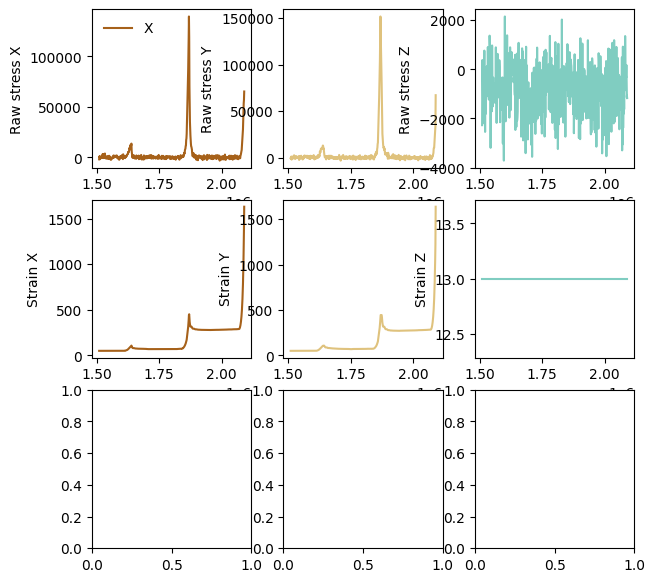

In [6]:
fig,ax = plt.subplots(3,3,figsize = (7,7))
ax[0,0].plot(Time,stressX,color = clrs[0],label = 'X')
ax[0,0].set_ylabel('Raw stress X')
ax[0,1].plot(Time,stressY,color = clrs[1],label = 'Y')
ax[0,1].set_ylabel('Raw stress Y')
ax[0,2].plot(Time,stressZ,color = clrs[2],label = 'Z')
ax[0,2].set_ylabel('Raw stress Z')
ax[1,0].plot(Time,xbox,color = clrs[0],label = 'X')
ax[1,0].set_ylabel('Strain X')
ax[1,1].plot(Time,ybox,color = clrs[1],label = 'Y')
ax[1,1].set_ylabel('Strain Y')
ax[1,2].plot(Time,np.ones(len(Time))*zbox,color = clrs[2],label = 'Z')
ax[1,2].set_ylabel('Strain Z')
ax[0,0].legend(frameon=False)

ax[2,0].plot(Time,stressXred,color = clrs[0],label = 'X')
ax[2,1].plot(Time,stressYred,color = clrs[0],label = 'Y')
ax[2,2].plot(Time,stressZred,color = clrs[0],label = 'Z')
ax[2,0].set_ylim([-0.025,0.1])
ax[2,1].set_ylim([-0.025,0.1])
ax[2,2].set_ylim([-0.025,0.1])
fig.tight_layout()

fig2,ax2 = plt.subplots(1,3,figsize = (6,2))
ax2[0].plot(np.multiply(press,-1),label = 'Press')
ax2[0].set_title('Press')
ax2[1].plot(np.add(np.add(stressXred,stressYred),stressZred),label = 'Stress')
ax2[1].set_title('Stress')
ax2[2].plot(np.multiply(AvBondForce,-1))
ax2[2].set_title('Av force on bonds')
#ax2[0].legend(frameon=False)
fig2.tight_layout()

In [ ]:
## Master plot showing reversible regime
#Strain X + Strain Y
#Stress X + Stress Y

fig,ax = plt.subplots(2,1,figsize = (4,5))

ax[0].plot(np.divide(np.add(Time,-Time[0]),1e6),np.add(stressXred,stressYred),color = ClrsRici[0])
ax[0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0].set_xticks([])
ax[1].plot(np.divide(np.add(Time,-Time[0]),1e6),np.mean([np.add(np.divide(np.multiply(xbox,100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox,100),ybox[0]),-100)],axis = 0),color = ClrsRici[2])
ax[1].set_ylabel(r'Strain, $\gamma_{x},\gamma_{y}~[\%]$',fontsize = 12)
ax[1].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
ax[1].set_ylim([-2,200])
fig.tight_layout()
#plotname = "Reversible_Stress.pdf"
#fig.savefig(plotsdir+plotname)

In [309]:
stressXred  =[]
stressYred  =[]
stressZred  =[]
#xboxx = []
#yboxx = []
meanstrain = []
### Fetching stress and bond force ####
Press = "-0.1".split()
#Press = "-0.05".split()
tcyclrel = "1e5".split()
seeds = "1 2 3".split()
T_End = 1200
for s in range(len(seeds)):
    foldername = datadir1+'run_Stress_tstretch1e4_tcycrel'+tcyclrel[0]+'_Press'+Press[0]+'_TimeFrom1509600_RheologyCycles5_seed'+seeds[s]+'/'
    
    filename = '/thermo.dat'
    thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
    etot_, ke_, peBond_,peAngle_, temp_, press_,stressX_,stressY_,stressZ_,AvBondForce_   = thermo.etot,thermo.ke,thermo.peBond,thermo.peAngle,thermo.temp,thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce     
    etot, ke, peBond,peAngle, temp, press,stressX,stressY,stressZ,AvBondForce = etot_.values, ke_.values, peBond_.values,peAngle_.values, temp_.values, press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values
    xbox_,ybox_ = thermo.boxX, thermo.boxY
    xbox,ybox = xbox_.values,ybox_.values
    Time_ = thermo.step
    Time = Time_.values
    print(len(Time))
    StressXTot.append(list(stressX))
    AvBondForceXTot.append(list(AvBondForce))
    zbox = 13
    stressXred.append(np.divide(stressX[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    stressYred.append(np.divide(stressY[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    stressZred.append(np.divide(stressZ[:T_End],np.multiply(np.multiply(xbox[:T_End],ybox[:T_End]),zbox)))
    xboxx.append(xbox)
    yboxx.append(ybox)
    meanstrain.append(np.multiply(np.add(np.divide(np.add(xbox[:T_End],ybox[:T_End]),np.add(ybox[0],xbox[0])),-1),100))
stressTotAv = np.mean(np.add(stressXred,stressYred),axis = 0)
stressTotStd = np.std(np.add(stressXred,stressYred),axis = 0)
meanstrainAv = np.mean(meanstrain,axis = 0)
meanstrainStd = np.std(meanstrain,axis = 0)
#xboxAv = np.mean(xboxx,axis = 0)
#yboxAv = np.mean(yboxx,axis = 0)
#MeanStrain = np.mean(np.mean([np.add(np.divide(np.multiply(xbox[:T_End],100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox[:T_End],100),ybox[0]),-100)],axis = 0))
#stressYredAv = np.mean(stressYred,axis = 0)


1296
1201
1238


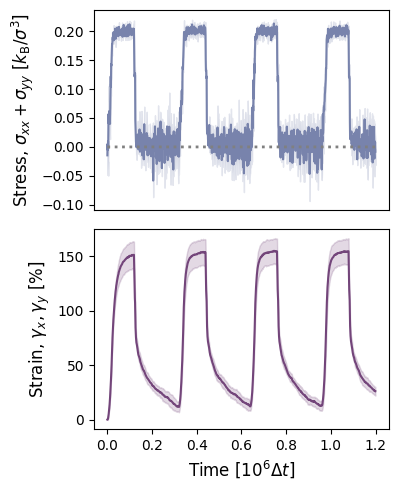

In [310]:
fig,ax = plt.subplots(2,1,figsize = (4,5))
#stressTotAv = np.add(stressXredAv,stressYredAv)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),stressTotAv,color = ClrsRici[0])
ax[0].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(stressTotAv,-stressTotStd),np.add(stressTotAv,stressTotStd),color = ClrsRici[0],alpha = 0.2)
ax[0].set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax[0].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.zeros(len(Time[:T_End])),linestyle = ':',color= 'grey',linewidth = 2)
ax[0].set_xticks([])
#ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.mean([np.add(np.divide(np.multiply(xbox[:T_End],100),xbox[0]),-100),np.add(np.divide(np.multiply(ybox[:T_End],100),ybox[0]),-100)],axis = 0),color = ClrsRici[2])
ax[1].plot(np.divide(np.add(Time[:T_End],-Time[0]),1e6),meanstrainAv,color = ClrsRici[2])
ax[1].fill_between(np.divide(np.add(Time[:T_End],-Time[0]),1e6),np.add(meanstrainAv,meanstrainStd),np.add(meanstrainAv,-meanstrainStd),color = ClrsRici[2],alpha = 0.2)
ax[1].set_ylabel(r'Strain, $\gamma_{x},\gamma_{y}~[\%]$',fontsize = 12)
ax[1].set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
fig.tight_layout()
plotname = "Reversible_StressSeedsPress"+Press[0]+".png"
fig.savefig(plotsdir+plotname)


In [49]:

# Helper function to extract the number 'N' from the filename

def extract_number_from_filename(filename):
    try:
        parts = filename.split('.')
        if len(parts) > 1:
            return int(parts[2])
    except ValueError:
        pass
    return float('inf')  # Assign a high value if no valid number is found

folder_path = datadir+'run_Stress_tstretch1e4_tcycrel5e4_Press-0.1_TimeFrom1509600_RheologyCycles5_seed1/dumplin/'

# List to store results
Xbox = []
Ybox = []
Zbox = []
TimeSteps = []
VolTime  =[]



files = [f for f in os.listdir(folder_path) if f.startswith("dump.") and os.path.isfile(os.path.join(folder_path, f))]
sorted_files = sorted(files, key=extract_number_from_filename)

for filename2 in sorted_files:
    file_path = os.path.join(folder_path, filename2)
    if os.path.isfile(file_path):
        with open(file_path, 'r') as file:
            lines = file.readlines()
            #print(lines[1].strip())
            TimeSteps.append(float(lines[1]))
            Xbox.append(float(lines[5].split(' ')[1])-float(lines[5].split(' ')[0]))
            Ybox.append(float(lines[6].split(' ')[1])-float(lines[6].split(' ')[0]))
            Zbox.append(float(lines[7].split(' ')[1])-float(lines[7].split(' ')[0]))
            VolTime.append((float(lines[5].split(' ')[1])-float(lines[5].split(' ')[0]))*(float(lines[6].split(' ')[1])-float(lines[6].split(' ')[0]))*(float(lines[7].split(' ')[1])-float(lines[7].split(' ')[0])))

stressXred=[]
stressYred=[]
stressZred=[]
for tt in range(len(TimeSteps)):
    for ttt in range(len(Time)):
        if TimeSteps[tt] == Time[ttt]:
            stressXred.append(stressX[ttt]/VolTime[tt])
            stressYred.append(stressY[ttt]/VolTime[tt])
            stressZred.append(stressZ[ttt]/VolTime[tt])    
print(Zbox)

[13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.